# Lab 05 — Image Segmentation (Tasks 1–10)


In [1]:
import urllib.request
from collections import deque
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IMG_DIR = Path("images"); IMG_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

OCV = "https://raw.githubusercontent.com/opencv/opencv/4.x"
SOURCES = {
    "sudoku.png":      [f"{OCV}/samples/data/sudoku.png"],
    "smarties.png":    [f"{OCV}/samples/data/smarties.png"],
    "water_coins.jpg": [f"{OCV}/doc/py_tutorials/py_imgproc/py_watershed/images/water_coins.jpg"],
    "dog.jpeg":        [],   # Packt OpenCV repo -> put dog.jpeg in images/ if auto-download is not possible
    "brain_mri.png":   [],   # brain MRI figure from the region-growing article -> put it in images/
}

def image_path(name):
    p = IMG_DIR / name
    if p.exists():
        return str(p)
    for url in SOURCES.get(name, []):
        try:
            urllib.request.urlretrieve(url, p)
            print("downloaded", name)
            return str(p)
        except Exception as e:
            print("download failed:", url, e)
    raise FileNotFoundError(f"Put '{name}' into the '{IMG_DIR}/' folder (see the Image Link sheet).")

def load_gray(name):
    img = cv2.imread(image_path(name), cv2.IMREAD_GRAYSCALE)
    assert img is not None, name
    return img

def load_color(name):
    img = cv2.imread(image_path(name), cv2.IMREAD_COLOR)
    assert img is not None, name
    return img

def to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img

def show_row(images, titles, fname=None, cols=None, size=3.6, suptitle=None, footer=None):
    n = len(images); cols = cols or n; rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows + (0.6 if footer else 0.2)))
    axes = np.atleast_1d(axes).ravel()
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(to_rgb(im), cmap="gray", vmin=0, vmax=255) if im.ndim == 2 else ax.imshow(to_rgb(im))
        ax.set_title(t, fontsize=9); ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    if suptitle: fig.suptitle(suptitle, fontsize=12)
    if footer: fig.text(0.5, 0.01, footer, ha="center", fontsize=10, style="italic", wrap=True)
    plt.tight_layout(rect=(0, 0.06 if footer else 0, 1, 1))
    if fname: fig.savefig(OUT_DIR / fname, dpi=130, bbox_inches="tight")
    plt.show()

## Task 1 — Document under uneven lighting (global vs adaptive)

downloaded sudoku.png
image size: (563, 558)
Percentage of pixels classified as 'ink' (black):
                            ink_total  ink_left  ink_right  ink_top  \
Global T=80                      25.8      40.8       10.8     12.7   
Global T=127                     74.7      96.8       52.6     65.3   
Global T=170                     98.7      99.9       97.5     97.4   
Adaptive (Gauss, 31, C=10)       15.3      13.8       16.7     16.8   

                            ink_bottom  
Global T=80                       38.9  
Global T=127                      84.1  
Global T=170                     100.0  
Adaptive (Gauss, 31, C=10)        13.7  


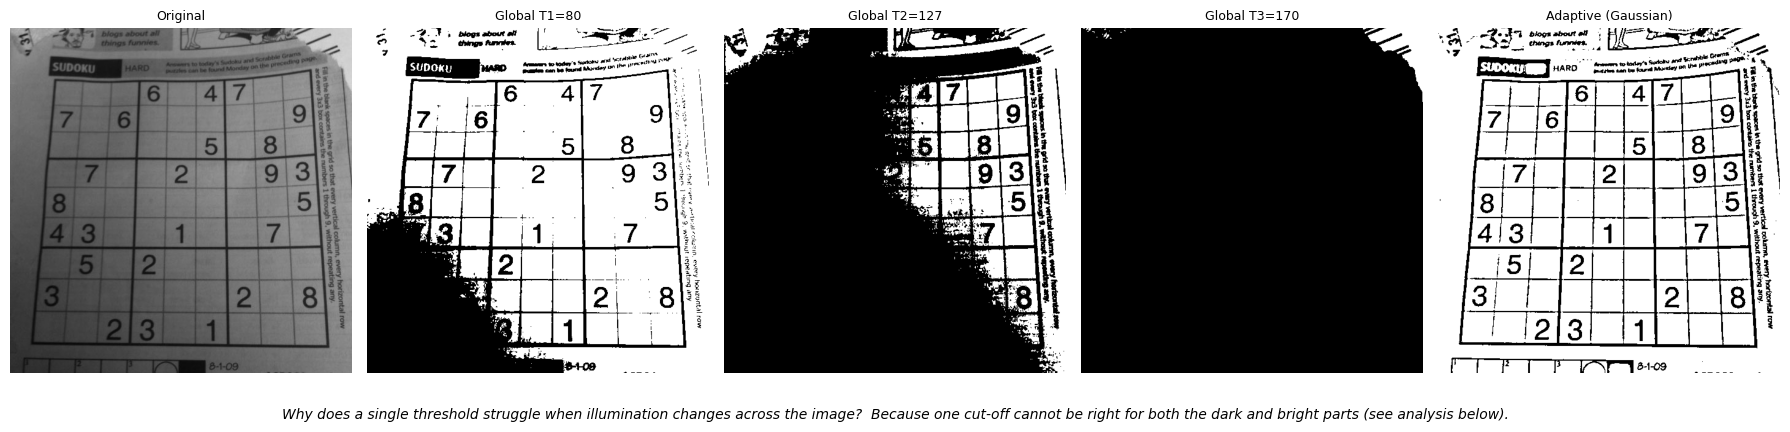

True

In [2]:
gray1 = load_gray("sudoku.png")
print("image size:", gray1.shape)

T = [80, 127, 170]
globals_ = [cv2.threshold(gray1, t, 255, cv2.THRESH_BINARY)[1] for t in T]
adaptive1 = cv2.adaptiveThreshold(gray1, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 10)

def ink_stats(mask):
    h, w = mask.shape
    black = (mask == 0)
    return dict(ink_total=100 * black.mean(),
                ink_left=100 * black[:, : w // 2].mean(),
                ink_right=100 * black[:, w // 2:].mean(),
                ink_top=100 * black[: h // 2].mean(),
                ink_bottom=100 * black[h // 2:].mean())

rows = {f"Global T={t}": ink_stats(m) for t, m in zip(T, globals_)}
rows["Adaptive (Gauss, 31, C=10)"] = ink_stats(adaptive1)
stats1 = pd.DataFrame(rows).T.round(1)
print("Percentage of pixels classified as 'ink' (black):")
print(stats1)

show_row([gray1] + globals_ + [adaptive1],
         ["Original", f"Global T1={T[0]}", f"Global T2={T[1]}", f"Global T3={T[2]}", "Adaptive (Gaussian)"],
         fname="task1_comparison.png",
         footer="Why does a single threshold struggle when illumination changes across the image?  "
                "Because one cut-off cannot be right for both the dark and bright parts (see analysis below).")
cv2.imwrite(str(OUT_DIR / "task1_final_adaptive_mask.png"), adaptive1)

Mean paper brightness (blurred) per quadrant:
  top-left     :   98.7
  top-right    :  125.9
  bottom-left  :   71.7
  bottom-right :  110.9

Darkest quadrant: bottom-left,  brightest quadrant: top-right
T= 80: ink in bottom-left =  66.5%   ink in top-right =  10.3%
T=127: ink in bottom-left = 100.0%   ink in top-right =  36.9%
T=170: ink in bottom-left = 100.0%   ink in top-right =  95.0%
Adaptive: ink in bottom-left =  13.1%   ink in top-right =  19.1%


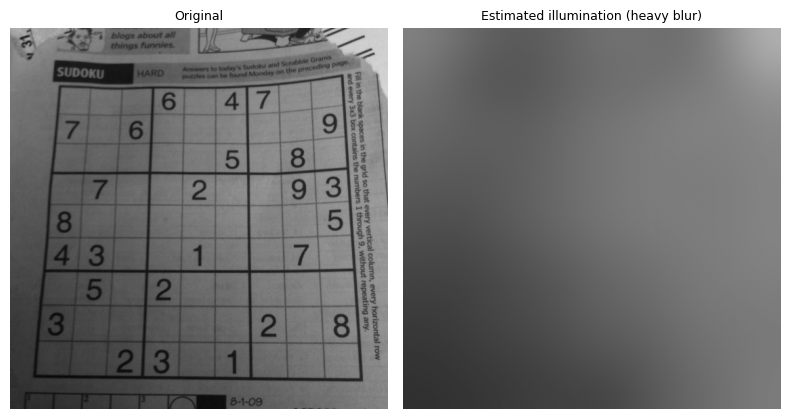

In [3]:
# Where does global thresholding fail?  Estimate the illumination field and compare brightness by region.
illum = cv2.GaussianBlur(gray1, (0, 0), sigmaX=max(gray1.shape) / 12)
h, w = gray1.shape
zones = {"top-left": illum[: h // 2, : w // 2], "top-right": illum[: h // 2, w // 2:],
         "bottom-left": illum[h // 2:, : w // 2], "bottom-right": illum[h // 2:, w // 2:]}
print("Mean paper brightness (blurred) per quadrant:")
for k, v in zones.items():
    print(f"  {k:13s}: {v.mean():6.1f}")

# which global threshold turns paper into 'ink' in the darkest / brightest quadrant?
darkest = min(zones, key=lambda k: zones[k].mean()); brightest = max(zones, key=lambda k: zones[k].mean())
print(f"\nDarkest quadrant: {darkest},  brightest quadrant: {brightest}")
sl = {"top-left": (slice(0, h // 2), slice(0, w // 2)), "top-right": (slice(0, h // 2), slice(w // 2, w)),
      "bottom-left": (slice(h // 2, h), slice(0, w // 2)), "bottom-right": (slice(h // 2, h), slice(w // 2, w))}
for t, m in zip(T, globals_):
    print(f"T={t:3d}: ink in {darkest} = {100*(m[sl[darkest]]==0).mean():5.1f}%   ink in {brightest} = {100*(m[sl[brightest]]==0).mean():5.1f}%")
print(f"Adaptive: ink in {darkest} = {100*(adaptive1[sl[darkest]]==0).mean():5.1f}%   ink in {brightest} = {100*(adaptive1[sl[brightest]]==0).mean():5.1f}%")

show_row([gray1, illum], ["Original", "Estimated illumination (heavy blur)"], size=4)

### Task 1 — analysis

* **Comparing the global masks:** a low T (80) keeps only the darkest pixels, so strokes in the brighter areas are fine but faint strokes / strokes in the shaded region break up; a high T (170) keeps the strokes but starts turning *shaded paper* into black blobs. T=127 sits in between and still fails on whichever side of the page is darkest. The per-quadrant table above shows the same paper being classified as ink in the dim quadrant while staying clean in the bright one.
* **Regions where global thresholding fails:** the **dim side of the page** (paper grey level falls close to / below the threshold → large unwanted black regions, or characters merging into the background) and the **bright side** when T is high enough that thin lines wash out. The illumination map above shows where that gradient is.
* **Adaptive vs best global:** adaptive thresholding computes a threshold per pixel from its neighbourhood (here a Gaussian-weighted mean − C), so the threshold follows the lighting. Characters and grid lines are recovered evenly across the whole page and the dim side no longer turns black.
* **Most usable mask:** Gaussian adaptive, `blockSize=31`, `C=10`.

**Why does a single threshold struggle when illumination changes across the image?** A global threshold assumes one grey level separates foreground from background everywhere. With uneven lighting the *paper* in the dark area can be darker than the *ink* in the bright area, so the two intensity populations overlap — no single value can separate them. A local threshold removes that dependence because it compares each pixel to its own surroundings.

## Task 2 — Choosing the adaptive-threshold strategy (blockSize, C, mean vs Gaussian)

  method  blockSize  C  ink_pct  speckles
    Mean          7  2    24.18      3519
    Mean          7 10    11.76       150
    Mean          7 25     4.68       580
    Mean         31  2    24.89       588
    Mean         31 10    17.38        73
    Mean         31 25    10.93       181
    Mean        151  2    25.24       155
    Mean        151 10    19.50       103
    Mean        151 25    12.78       159
Gaussian          7  2    20.52      5447
Gaussian          7 10     8.32       530
Gaussian          7 25     0.82       705
Gaussian         31  2    23.90      1123
Gaussian         31 10    15.27        76
Gaussian         31 25     8.80       330
Gaussian        151  2    23.91       220
Gaussian        151 10    18.33        64
Gaussian        151 25    12.13       187


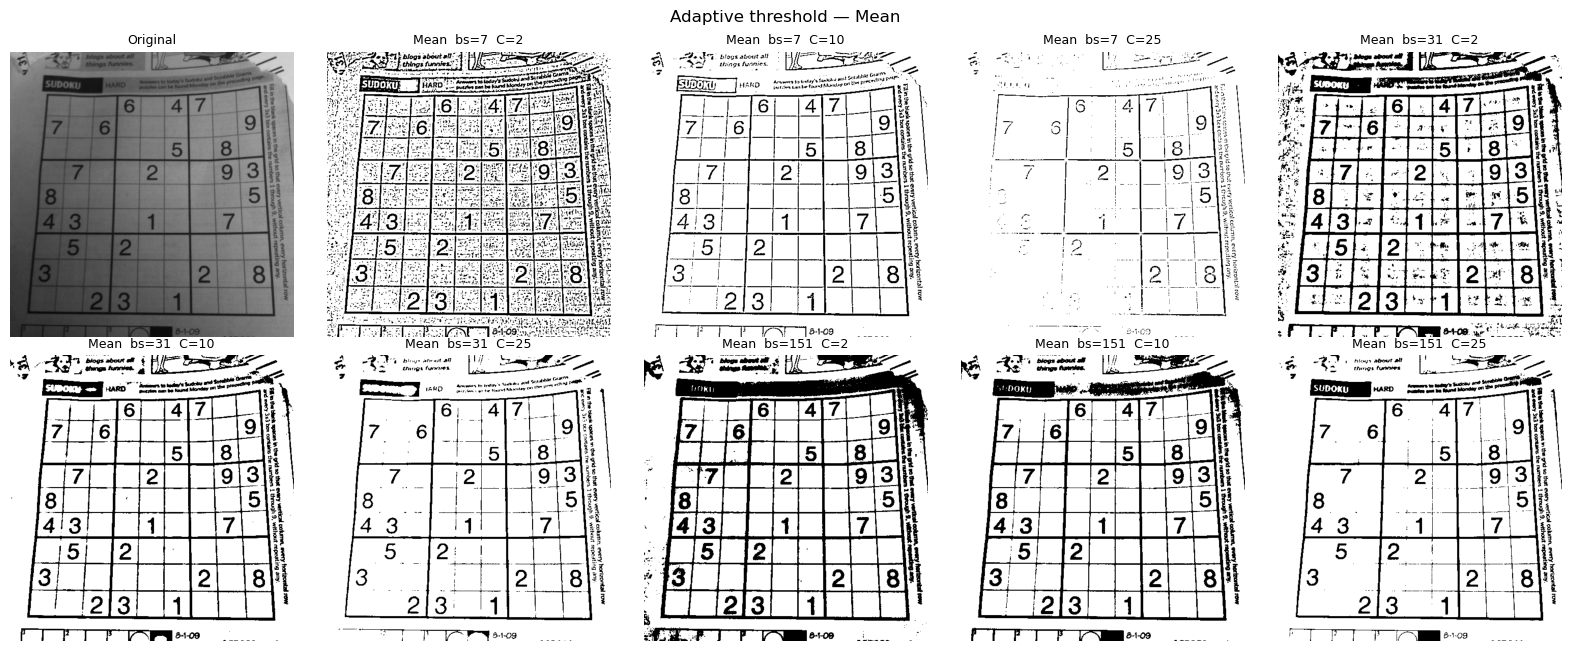

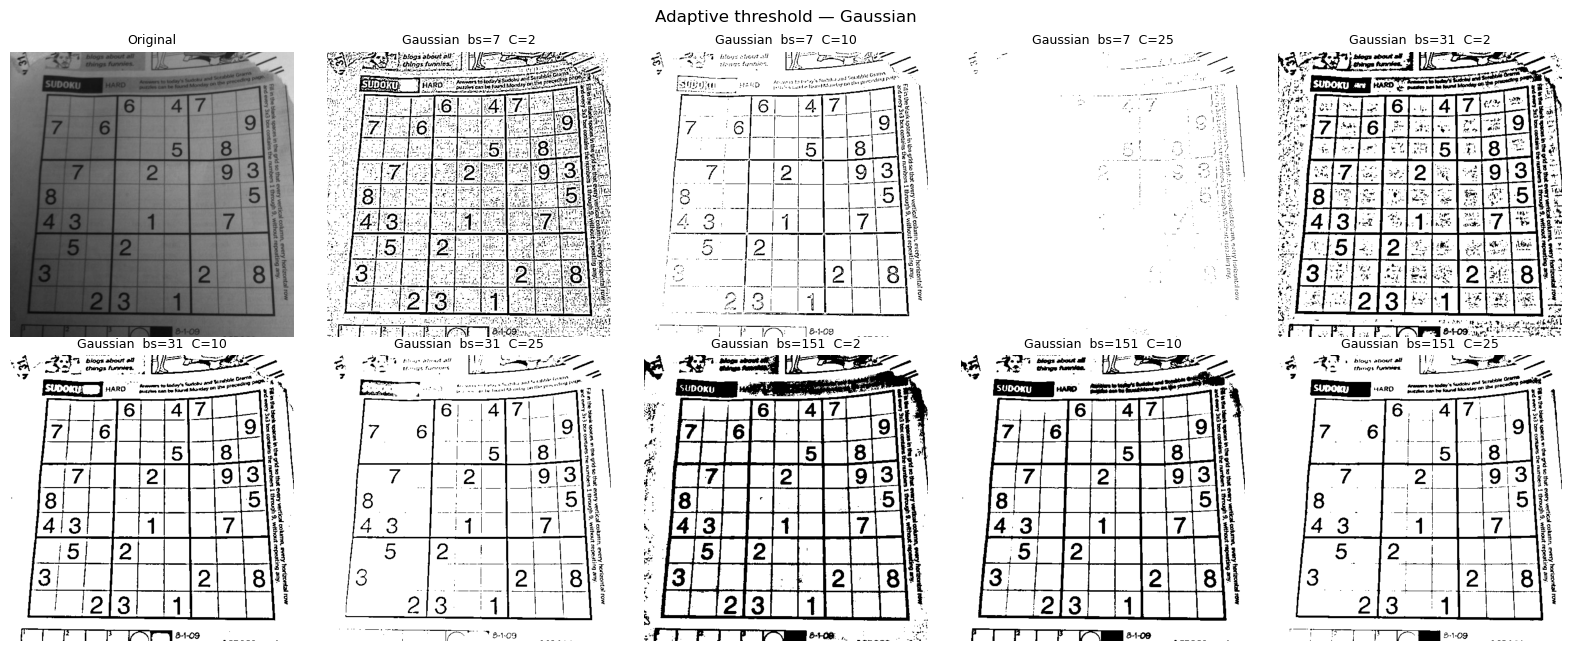

In [4]:
gray2 = load_gray("sudoku.png")
block_sizes = [7, 31, 151]
C_values = [2, 10, 25]
methods = {"Mean": cv2.ADAPTIVE_THRESH_MEAN_C, "Gaussian": cv2.ADAPTIVE_THRESH_GAUSSIAN_C}

def speckles(mask, max_area=6):
    black = (mask == 0).astype(np.uint8)
    n, _, st, _ = cv2.connectedComponentsWithStats(black, connectivity=8)
    return int((st[1:, cv2.CC_STAT_AREA] <= max_area).sum())

results2, records = {}, []
for mname, mflag in methods.items():
    for bs in block_sizes:
        for C in C_values:
            m = cv2.adaptiveThreshold(gray2, 255, mflag, cv2.THRESH_BINARY, bs, C)
            results2[(mname, bs, C)] = m
            records.append(dict(method=mname, blockSize=bs, C=C,
                                ink_pct=round(100 * (m == 0).mean(), 2), speckles=speckles(m)))
table2 = pd.DataFrame(records)
print(table2.to_string(index=False))

for mname in methods:
    imgs = [gray2] + [results2[(mname, bs, C)] for bs in block_sizes for C in C_values]
    titles = ["Original"] + [f"{mname}  bs={bs}  C={C}" for bs in block_sizes for C in C_values]
    show_row(imgs, titles, cols=5, size=3.2, fname=f"task2_{mname.lower()}_grid.png",
             suptitle=f"Adaptive threshold — {mname}")

                   ink_pct               speckles              
C                       2      10     25       2      10     25
method   blockSize                                             
Gaussian 7           20.52   8.32   0.82   5447.0  530.0  705.0
         31          23.90  15.27   8.80   1123.0   76.0  330.0
         151         23.91  18.33  12.13    220.0   64.0  187.0
Mean     7           24.18  11.76   4.68   3519.0  150.0  580.0
         31          24.89  17.38  10.93    588.0   73.0  181.0
         151         25.24  19.50  12.78    155.0  103.0  159.0

Cleanest candidates (low speckles, plausible ink %):
  method  blockSize  C  ink_pct  speckles
Gaussian        151 10    18.33        64
    Mean         31 10    17.38        73
Gaussian         31 10    15.27        76
    Mean        151 10    19.50       103
    Mean          7 10    11.76       150

Best combination -> {'method': 'Gaussian', 'blockSize': np.int64(151), 'C': np.int64(10), 'ink_pct': np.float64(18.33

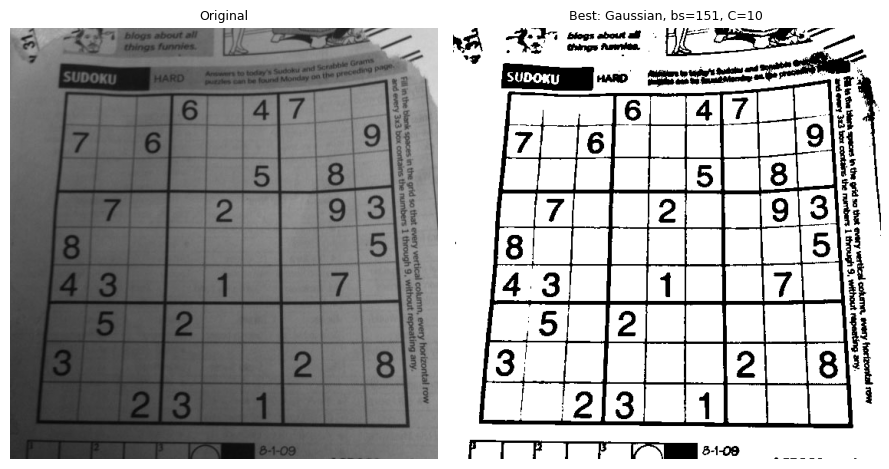

In [5]:
# Summaries that answer the five questions
piv = table2.pivot_table(index=["method", "blockSize"], columns="C", values=["ink_pct", "speckles"])
print(piv.round(2).to_string())

# 'cleanest' = fewest speckles among results whose ink% is within a plausible band of the median ink%
med = table2.ink_pct.median()
cand = table2[(table2.ink_pct > 0.3 * med) & (table2.ink_pct < 2.0 * med)].sort_values(["speckles", "ink_pct"])
print("\nCleanest candidates (low speckles, plausible ink %):")
print(cand.head(5).to_string(index=False))
best = cand.iloc[0]
print("\nBest combination ->", dict(best))
print("\nAverage speckles by method:\n", table2.groupby("method").speckles.mean().round(1).to_string())

best_mask = results2[(best.method, int(best.blockSize), int(best.C))]
cv2.imwrite(str(OUT_DIR / "task2_final_best_mask.png"), best_mask)
show_row([gray2, best_mask], ["Original", f"Best: {best.method}, bs={int(best.blockSize)}, C={int(best.C)}"], size=4.5)

### Task 2 — analysis (read together with the grids and tables above)

1. **Neighbourhood too small** (bs=7): the window sees only a stroke and a little paper, so inside a thick stroke the local mean *equals* the pixel value → interior becomes "background" → **hollow/broken characters** and a large number of isolated speckles from paper texture.
2. **Neighbourhood too large** (bs=151): the window spans a big part of the page, including the lighting gradient, so the result drifts back towards a **global threshold** — shading starts to leak through and dim-side strokes weaken. It also blurs local contrast, so thin grid lines can disappear.
3. **Increasing C:** the threshold is `local_mean − C`, so a larger C makes it *harder* to be black. Noise and speckles drop sharply (cleaner), but if C is too big, faint or thin strokes break up and ink % collapses. Small C → "excessive black noise" around the letters.
4. **Cleanest combination:** printed by the selection cell above (a medium neighbourhood with moderate C normally balances both failure modes). Confirm visually that strokes are complete, not only that speckles are low.
5. **Mean vs Gaussian:** the mean window weights all pixels equally, so strong ink pixels inside the window shift the mean and create halos/noise; the Gaussian window weights the centre more and falls off smoothly, which normally gives a smoother local threshold. Decide for **your** image from the *average speckles by method* output and the two grids above, and state the winner in your report.

## Task 3 — Otsu's thresholding (coins)

downloaded water_coins.jpg
                            Otsu threshold  Foreground %
Raw                                  162.0          55.9
Gaussian blur 5x5                    162.0          56.5
Contrast up (a=1.5,b=-40)            173.0          54.9
Contrast down (a=0.6,b=40)           137.0          55.9
CLAHE                                159.0          55.5


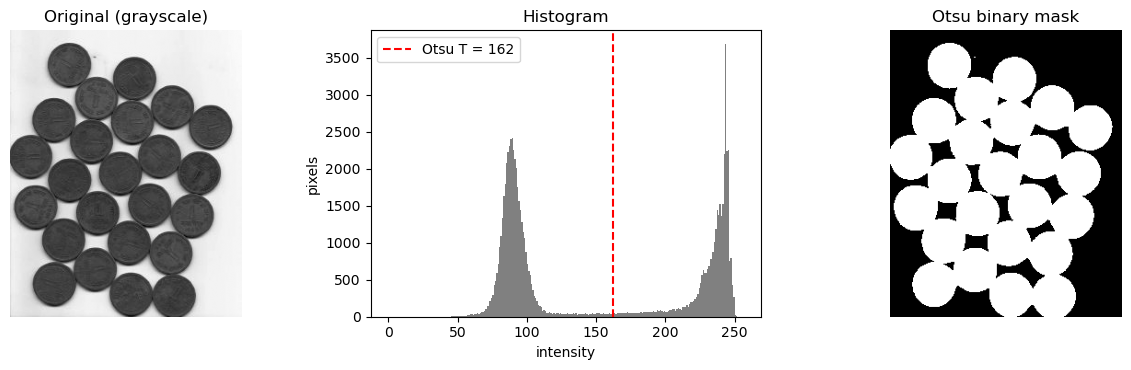

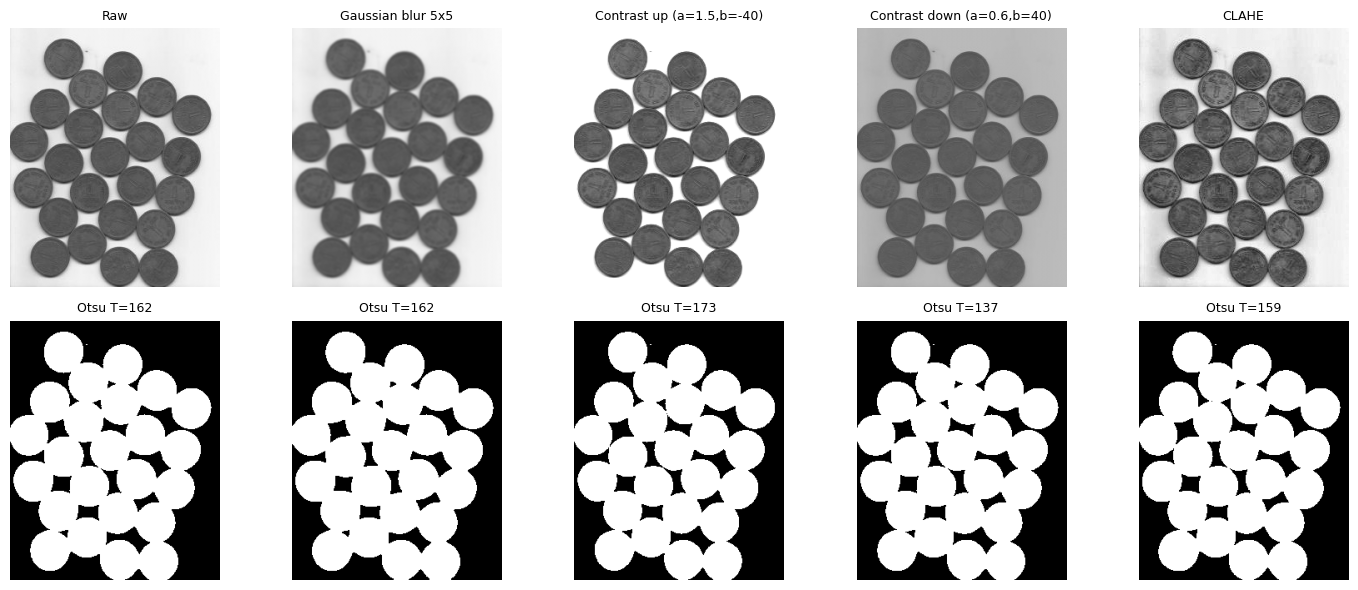

In [6]:
gray3 = load_gray("water_coins.jpg")
variants = {
    "Raw": gray3,
    "Gaussian blur 5x5": cv2.GaussianBlur(gray3, (5, 5), 0),
    "Contrast up (a=1.5,b=-40)": cv2.convertScaleAbs(gray3, alpha=1.5, beta=-40),
    "Contrast down (a=0.6,b=40)": cv2.convertScaleAbs(gray3, alpha=0.6, beta=40),
    "CLAHE": cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray3),
}
otsu = {}
for name, im in variants.items():
    t, m = cv2.threshold(im, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    otsu[name] = (t, m)
tab3 = pd.DataFrame({"Otsu threshold": {k: v[0] for k, v in otsu.items()},
                     "Foreground %": {k: round(100 * (v[1] > 0).mean(), 1) for k, v in otsu.items()}})
print(tab3.to_string())

# Required output: Original -> Histogram -> Otsu Binary Mask
t_raw, mask_raw = otsu["Raw"]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].imshow(gray3, cmap="gray"); ax[0].set_title("Original (grayscale)"); ax[0].axis("off")
ax[1].hist(gray3.ravel(), bins=256, range=(0, 256), color="gray")
ax[1].axvline(t_raw, color="r", ls="--", label=f"Otsu T = {t_raw:.0f}")
ax[1].set_title("Histogram"); ax[1].set_xlabel("intensity"); ax[1].set_ylabel("pixels"); ax[1].legend()
ax[2].imshow(mask_raw, cmap="gray"); ax[2].set_title("Otsu binary mask"); ax[2].axis("off")
plt.tight_layout(); fig.savefig(OUT_DIR / "task3_original_hist_otsu.png", dpi=130, bbox_inches="tight"); plt.show()

# Effect of preprocessing
show_row([v for v in variants.values()] + [otsu[k][1] for k in variants],
         [f"{k}" for k in variants] + [f"Otsu T={otsu[k][0]:.0f}" for k in variants],
         cols=5, size=2.9, fname="task3_preprocessing_comparison.png")

### Task 3 — analysis

* **Comparing automatic thresholds:** the table above shows how Otsu's threshold moves when the image changes. A contrast stretch/compression shifts the whole histogram, so Otsu's T shifts with it while the resulting *mask* (see Foreground %) should stay similar — Otsu adapts to the histogram instead of hard-coding a grey level. Compare the thresholds and masks in the table/figure for blur and CLAHE, which change the histogram shape, and note any variant whose mask differs visibly.
* **Why is Otsu useful when the programmer does not know the correct threshold beforehand?** The histogram is expected to have two classes (object + background). Otsu searches all 256 candidate thresholds and picks the one that best separates those two classes (minimum within-class variance / maximum between-class variance). Therefore the threshold is derived from each image's own data, removing manual tuning and making the pipeline robust to exposure / contrast changes between images — exactly what the quality-control engineer needs. (It would fail only if the histogram were not roughly bimodal, e.g. strong lighting gradients.)

## Task 4 — Sorting objects by colour (HSV)

downloaded smarties.png
restrictive  lower=(58, 230, 230) upper=(62, 255, 255)  -> 0 pixels (0.00% of image)
final        lower=(35, 70, 50) upper=(85, 255, 255)  -> 5414 pixels (3.68% of image)
  lower S =   0  -> 9153 pixels
  lower S =  70  -> 5414 pixels
  lower S = 150  -> 5159 pixels
  lower S = 230  -> 4851 pixels


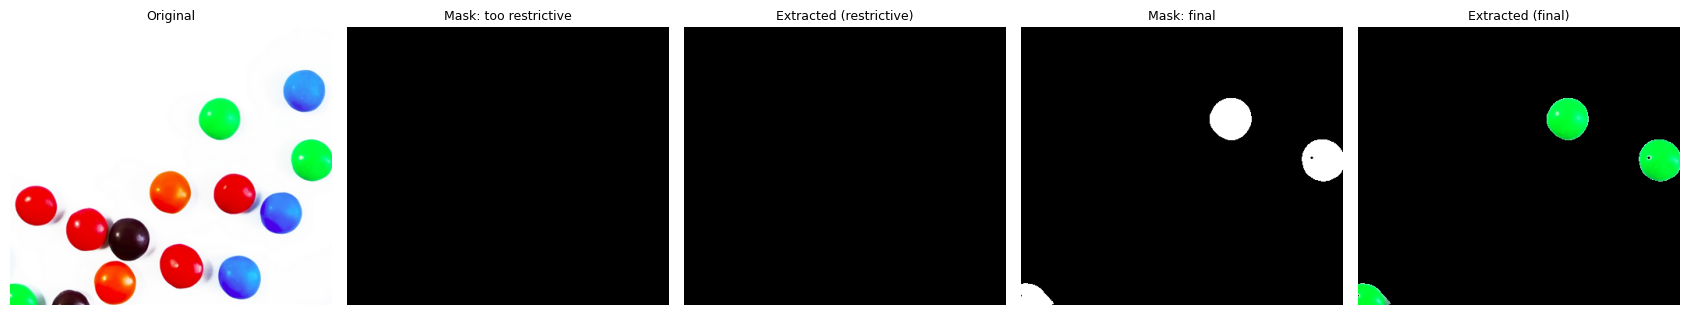

True

In [7]:
img4 = load_color("smarties.png")
hsv4 = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)

TARGET = {"restrictive": ((58, 230, 230), (62, 255, 255)),
          "final":       ((35, 70, 50),   (85, 255, 255))}

masks4, extracted4 = {}, {}
for k, (lo, hi) in TARGET.items():
    m = cv2.inRange(hsv4, np.array(lo), np.array(hi))
    masks4[k] = m
    extracted4[k] = cv2.bitwise_and(img4, img4, mask=m)
    print(f"{k:12s} lower={lo} upper={hi}  -> {int((m>0).sum())} pixels ({100*(m>0).mean():.2f}% of image)")

# small experiment on the limits (step 5 of the task): vary the lower saturation limit
for s_lo in [0, 70, 150, 230]:
    m = cv2.inRange(hsv4, np.array((35, s_lo, 50)), np.array((85, 255, 255)))
    print(f"  lower S = {s_lo:3d}  -> {int((m>0).sum())} pixels")

show_row([img4, masks4["restrictive"], extracted4["restrictive"], masks4["final"], extracted4["final"]],
         ["Original", "Mask: too restrictive", "Extracted (restrictive)", "Mask: final", "Extracted (final)"],
         fname="task4_hsv_masks.png", size=3.4)
cv2.imwrite(str(OUT_DIR / "task4_final_mask.png"), masks4["final"])
cv2.imwrite(str(OUT_DIR / "task4_final_extracted.png"), extracted4["final"])

### Task 4 — why the restrictive mask fails

The restrictive mask accepts only a ~5-unit hue slice **and** only almost fully saturated, almost maximum-brightness pixels. Real objects are 3-D and lit unevenly: the same green candy contains darker shaded pixels (low V), pale specular highlights (low S) and slightly different hues from camera noise/JPEG compression. All of those fall outside the narrow box, so the mask captures only a few scattered pixels (or nothing) instead of the whole object — a robot would see fragments and could not locate the candy. Widening H, and lowering the S/V minimums to just above the background level, captures the full object while still rejecting the background. HSV works because **hue** (the colour) is separated from **intensity**, which is exactly what plain grayscale thresholding (Tasks 1–3) cannot do.

## Task 5 — Canny edge detection with hysteresis

low= 50 high= 80 ->   3328 edge pixels
low= 50 high=150 ->   3038 edge pixels
low= 50 high=300 ->   2698 edge pixels


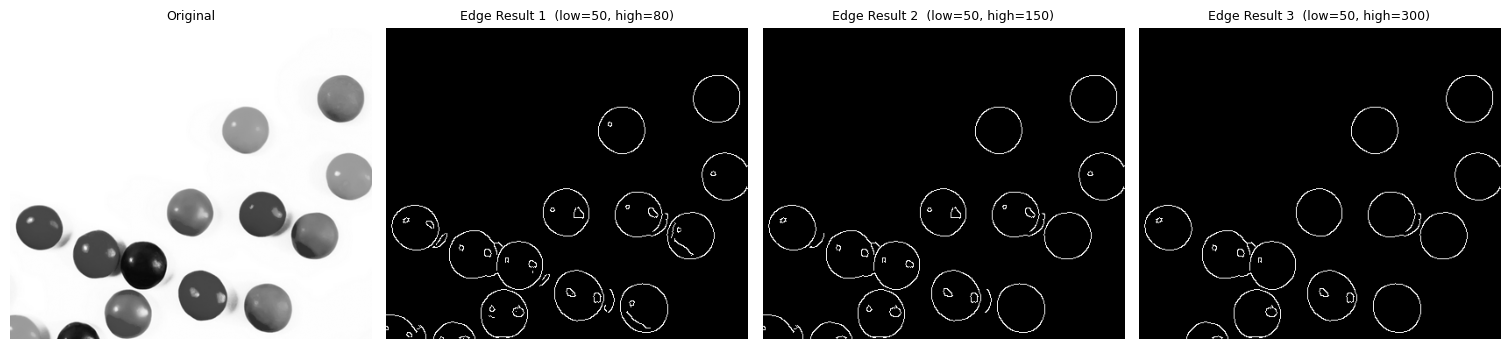

In [8]:
gray5 = load_gray("smarties.png")
blur5 = cv2.GaussianBlur(gray5, (5, 5), 1.4)
pairs = [(50, 80), (50, 150), (50, 300)]
edges5 = [cv2.Canny(blur5, lo, hi) for lo, hi in pairs]
for (lo, hi), e in zip(pairs, edges5):
    print(f"low={lo:3d} high={hi:3d} -> {int((e>0).sum()):6d} edge pixels")

show_row([gray5] + edges5, ["Original"] + [f"Edge Result {i+1}  (low={lo}, high={hi})" for i, (lo, hi) in enumerate(pairs)],
         fname="task5_canny_comparison.png", size=3.8)

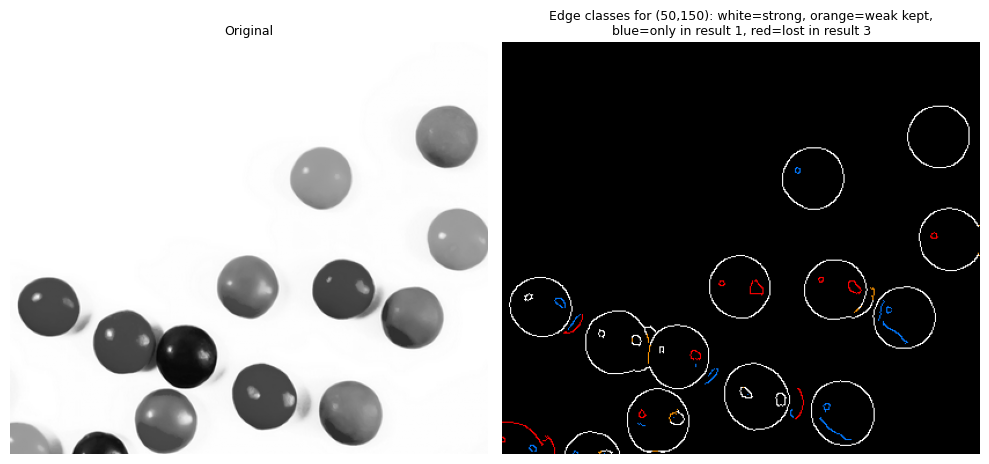

strong pixels: 2853  weak(kept): 185  only-in-result-1: 290  lost in result 3: 340


In [9]:
# Visualise strong / weak / missing / unwanted edges
gx = cv2.Sobel(blur5, cv2.CV_32F, 1, 0, ksize=3); gy = cv2.Sobel(blur5, cv2.CV_32F, 0, 1, ksize=3)
mag = np.abs(gx) + np.abs(gy)   # cv2.Canny's default (L1) gradient magnitude, so it is directly comparable to low/high

lo, hi = pairs[1]
e_mid = edges5[1] > 0
strong = e_mid & (mag > hi)
weak = e_mid & ~strong
missing = (edges5[0] > 0) & ~(edges5[2] > 0)   # present at the sensitive setting, lost at the strict one

vis = np.zeros((*gray5.shape, 3), np.uint8)
vis[strong] = (255, 255, 255)        # white  = strong
vis[weak] = (0, 150, 255)            # orange (BGR) = weak but connected (kept)
vis[(edges5[0] > 0) & ~e_mid] = (255, 120, 0)   # blue (BGR) = kept only by the sensitive pair (weak / possibly unwanted)
vis[missing & e_mid] = (0, 0, 255)   # red (BGR) = lost in result 3 although real (missing edge at high threshold)
show_row([gray5, vis],
         ["Original", "Edge classes for (50,150): white=strong, orange=weak kept,\nblue=only in result 1, red=lost in result 3"], size=5)
print("strong pixels:", int(strong.sum()), " weak(kept):", int(weak.sum()),
      " only-in-result-1:", int(((edges5[0] > 0) & ~e_mid).sum()), " lost in result 3:", int((missing & e_mid).sum()))

### Task 5 — analysis

* **Strong edges:** the high-contrast outlines between each candy and the dark background (and the strongest internal highlights). They survive even Edge Result 3.
* **Weak edges:** lower-contrast parts of the outlines (shaded sides of the candies, printed lettering, soft highlights). They are kept only when connected to a strong edge — visible as the orange pixels and as the difference between results 1→2→3.
* **Missing edges:** with a high threshold of 300 many real boundary segments are no longer connected to any strong seed and disappear → broken outlines (compare Result 3 with Result 2).
* **Unwanted edges:** with the sensitive pair (50, 80) texture, noise, lettering on the candies and JPEG/compression artefacts become edges (extra pixels in Result 1) that do not belong to the object boundary.
* **Effect of the thresholds:** *Low threshold* controls how far an edge may extend along weak gradients (lower → longer, more connected edges but more noise). *High threshold* controls which edges may **start** at all (higher → fewer seeds → fewer, cleaner edges, but real weak boundaries lose their seed and vanish). Keeping low = 50 fixed while raising high from 80 → 150 → 300 demonstrates this: the edge pixel count falls and outlines go from noisy/complete → clean/complete → clean/broken. The middle setting (50, 150) is the best compromise for finding the part boundary.

## Task 6 — Region growing on a brain MRI

MRI size: (371, 442)
seeds (row, col): {'Seed A': (185, 221), 'Seed B': (206, 169)}  intensities: {'Seed A': 164, 'Seed B': 230}


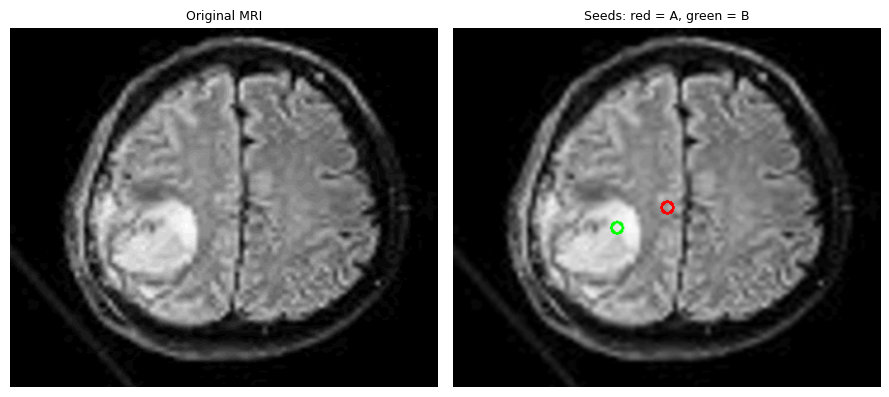

  seed    seed_xy  intensity  threshold  region_pixels  area_pct
Seed A (185, 221)        164         10            484      0.30
Seed A (185, 221)        164         25          16291      9.93
Seed A (185, 221)        164         45          43194     26.34
Seed B (206, 169)        230         10            676      0.41
Seed B (206, 169)        230         25           2700      1.65
Seed B (206, 169)        230         45           4230      2.58


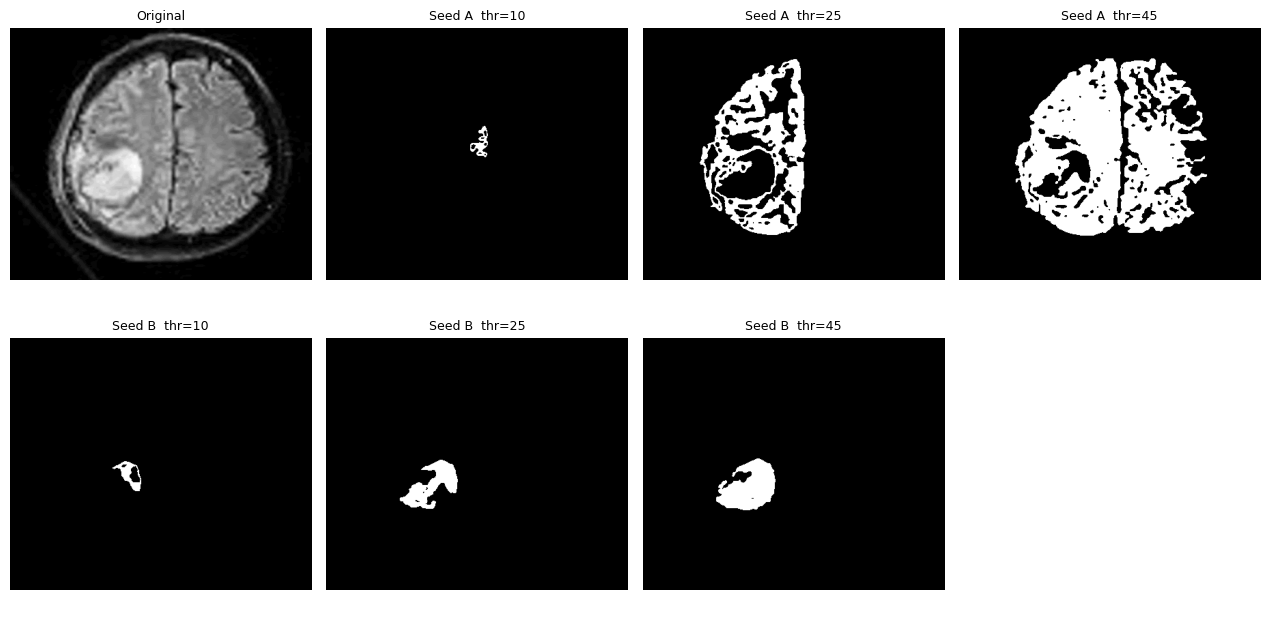

True

In [12]:
mri = load_gray("brain_mri.png")
MAX_SIDE = 512
if max(mri.shape) > MAX_SIDE:                      # keep the pure-Python growth fast
    s = MAX_SIDE / max(mri.shape)
    mri = cv2.resize(mri, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
mri_s = cv2.GaussianBlur(mri, (3, 3), 0)
H, W = mri_s.shape
print("MRI size:", mri_s.shape)

def region_grow(img, seed, thr):
    # Grow from seed=(row, col); a neighbour joins if |I - I_seed| <= thr (8-connected).
    h, w = img.shape
    ref = int(img[seed])
    mask = np.zeros((h, w), np.uint8)
    mask[seed] = 255
    q = deque([seed])
    while q:
        r, c = q.popleft()
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0:
                    continue
                rr, cc = r + dr, c + dc
                if 0 <= rr < h and 0 <= cc < w and mask[rr, cc] == 0 and abs(int(img[rr, cc]) - ref) <= thr:
                    mask[rr, cc] = 255
                    q.append((rr, cc))
    return mask

SEED_A = (H // 2, W // 2)
bright = cv2.GaussianBlur(mri_s, (0, 0), 15)
SEED_B = tuple(int(v) for v in np.unravel_index(np.argmax(bright), bright.shape))
SEEDS = {"Seed A": SEED_A, "Seed B": SEED_B}
THRS = [10, 25, 45]
print("seeds (row, col):", SEEDS, " intensities:", {k: int(mri_s[v]) for k, v in SEEDS.items()})

# seeds on the image
vis = cv2.cvtColor(mri_s, cv2.COLOR_GRAY2BGR)
for (r, c), col in zip(SEEDS.values(), [(0, 0, 255), (0, 255, 0)]):
    cv2.circle(vis, (c, r), 6, col, 2)
show_row([mri, vis], ["Original MRI", "Seeds: red = A, green = B"], size=4.5)

grown, rows6 = {}, []
for sname, seed in SEEDS.items():
    for t in THRS:
        m = region_grow(mri_s, seed, t)
        grown[(sname, t)] = m
        rows6.append(dict(seed=sname, seed_xy=seed, intensity=int(mri_s[seed]), threshold=t,
                          region_pixels=int((m > 0).sum()), area_pct=round(100 * (m > 0).mean(), 2)))
print(pd.DataFrame(rows6).to_string(index=False))

imgs, titles = [], []
for sname in SEEDS:
    for t in THRS:
        imgs.append(grown[(sname, t)]); titles.append(f"{sname}  thr={t}")
show_row([mri] + imgs, ["Original"] + titles, cols=4, size=3.2, fname="task6_region_growing.png")
cv2.imwrite(str(OUT_DIR / "task6_final_mask_seedA_thr25.png"), grown[("Seed A", 25)])

### Task 6 — analysis

* **Threshold effect:** a small threshold (10) accepts only pixels almost identical to the seed → small, fragmented region; a medium threshold (25) fills the homogeneous structure; a large threshold (45) *leaks* through weak boundaries into neighbouring tissue (the area jumps — see the `area_pct` column).
* **Why can changing the seed point significantly change the final segmented region?** Region growing is **not** a per-pixel classification: the membership test compares neighbours to the *seed's intensity* and the region can only expand through **connected** pixels that pass the test. A different seed (1) has a different reference intensity, so a different set of grey levels is accepted; (2) lies in a different connected component, so even identical-looking tissue elsewhere is unreachable; and (3) may sit on noise/an edge pixel whose value is unrepresentative of its tissue. Because MRI tissues have overlapping intensities, a global threshold cannot isolate one structure, but region growing + a well-chosen seed can — at the cost of being seed-dependent.

## Task 7 — Marker-based watershed on touching coins

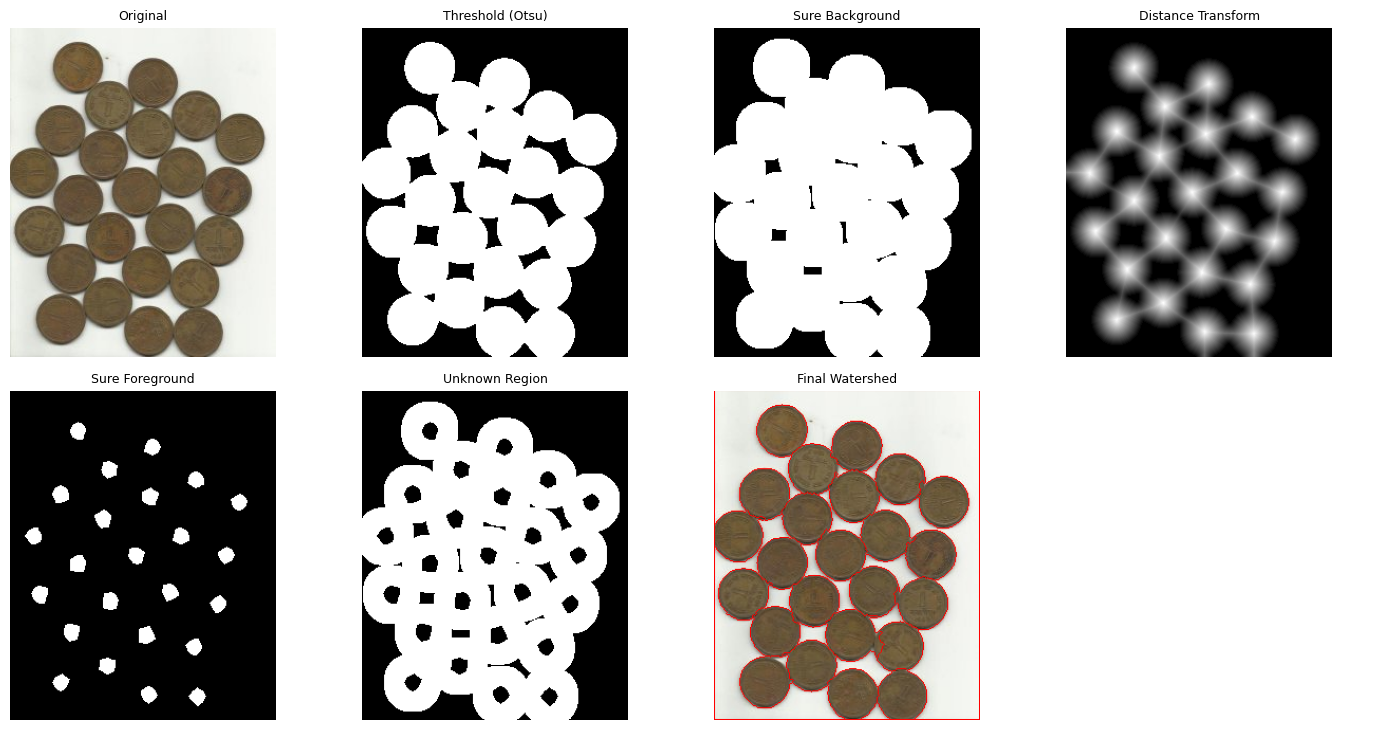

foreground markers: 24,  coins separated by watershed: 24
Plain connected components of the thresholded mask: 1 (lower than the watershed count whenever coins touch)


In [13]:
coins = load_color("water_coins.jpg")

def watershed_pipeline(img_bgr, dist_frac=0.7):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, dist_frac * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    n_labels, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    out = img_bgr.copy()
    markers = cv2.watershed(out, markers)
    out[markers == -1] = (0, 0, 255)               # red boundaries
    return dict(thresh=thresh, opening=opening, sure_bg=sure_bg, dist=dist, sure_fg=sure_fg, unknown=unknown,
                markers=markers, result=out, n_markers=n_labels - 1)

st = watershed_pipeline(coins, 0.7)
dist_vis = cv2.normalize(st["dist"], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
show_row([coins, st["thresh"], st["sure_bg"], dist_vis, st["sure_fg"], st["unknown"], st["result"]],
         ["Original", "Threshold (Otsu)", "Sure Background", "Distance Transform", "Sure Foreground",
          "Unknown Region", "Final Watershed"], cols=4, size=3.6, fname="task7_watershed_pipeline.png")
cv2.imwrite(str(OUT_DIR / "task7_final_watershed.png"), st["result"])
regions = [l for l in np.unique(st["markers"]) if l >= 2]
print(f"foreground markers: {st['n_markers']},  coins separated by watershed: {len(regions)}")
print("Plain connected components of the thresholded mask:", cv2.connectedComponents(st["opening"])[0] - 1,
      "(lower than the watershed count whenever coins touch)")

**Visual inspection (Task 7):** in the final panel the red watershed lines cut through the contact points of touching coins, giving each coin its own region. Counting connected components of the plain threshold (printed above) returns fewer objects than the watershed count whenever coins touch — that difference is exactly the error the system had to remove.

---

## Task 8 — Tuning the distance-transform threshold

 Experiment Distance Threshold  Foreground (markers)  Regions (separated)                                    Observed Result
          1          0.3 x max                     1                    1 Some coins lost / merged (cores vanished or fused)
          2          0.5 x max                    24                   24               Most meaningful: one region per coin
          3          0.7 x max                    24                   24               Most meaningful: one region per coin
          4          0.9 x max                    24                   24               Most meaningful: one region per coin

extra metric (largest region / median region area): [1.0, 1.08, 1.11, 1.11]


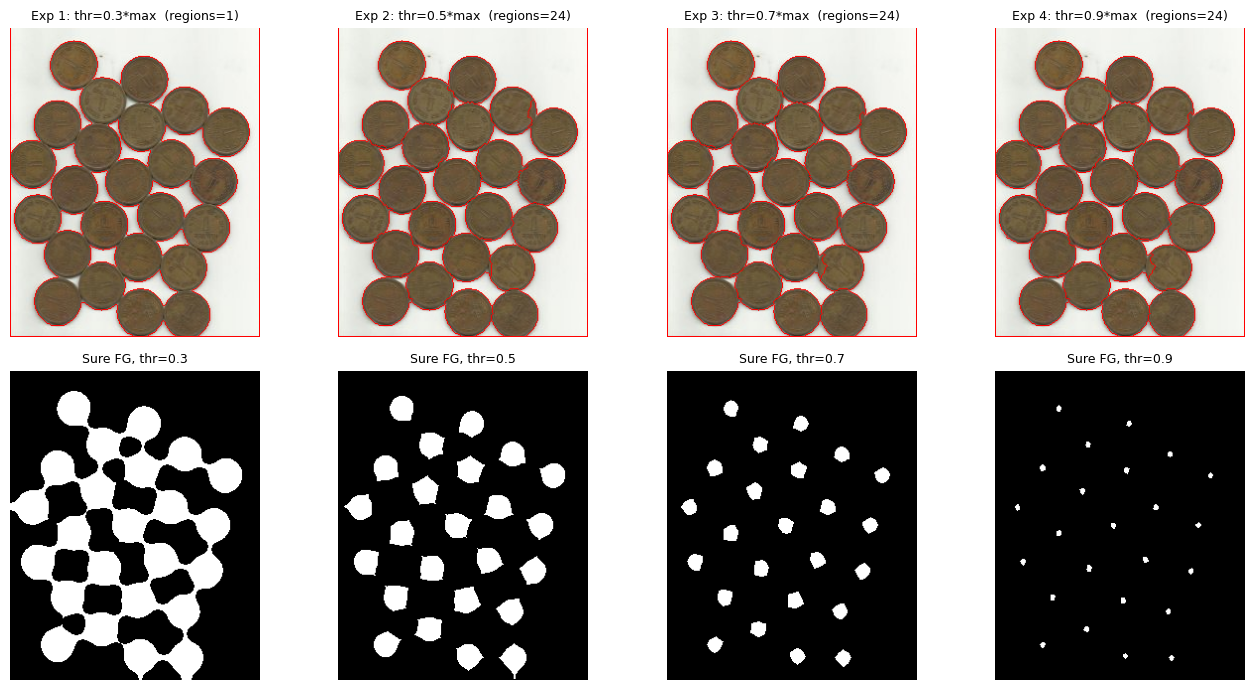

In [14]:
fracs = [0.3, 0.5, 0.7, 0.9]
runs = [watershed_pipeline(coins, f) for f in fracs]

def region_areas(markers):
    labs = [l for l in np.unique(markers) if l >= 2]
    return np.array([(markers == l).sum() for l in labs])

rows8 = []
for f, r in zip(fracs, runs):
    a = region_areas(r["markers"])
    rows8.append(dict(frac=f, n_markers=r["n_markers"], n_regions=len(a),
                      max_over_median=round(a.max() / np.median(a), 2) if len(a) else np.nan))
df8 = pd.DataFrame(rows8)
plateau = int(df8.n_regions.mode().iloc[0])

def verdict(row):
    if row.max_over_median > 1.8 and row.n_regions <= plateau:
        return "Under-segmented: cores merged, coins stay joined"
    if row.n_regions > plateau:
        return "Over-segmented: some coins split into several regions"
    if row.n_regions < plateau:
        return "Some coins lost / merged (cores vanished or fused)"
    return "Most meaningful: one region per coin"
df8["Observed Result"] = df8.apply(verdict, axis=1)

table8 = pd.DataFrame({"Experiment": range(1, 5),
                       "Distance Threshold": [f"{f:.1f} x max" for f in fracs],
                       "Foreground (markers)": df8.n_markers,
                       "Regions (separated)": df8.n_regions,
                       "Observed Result": df8["Observed Result"]})
print(table8.to_string(index=False))
print("\nextra metric (largest region / median region area):", df8.max_over_median.tolist())

show_row([r["result"] for r in runs] + [r["sure_fg"] for r in runs],
         [f"Exp {i+1}: thr={f:.1f}*max  (regions={r['n_markers']})" for i, (f, r) in enumerate(zip(fracs, runs))]
         + [f"Sure FG, thr={f:.1f}" for f in fracs], cols=4, size=3.4, fname="task8_distance_threshold_study.png")
table8.to_csv(OUT_DIR / "task8_table.csv", index=False)

### Task 8 — analysis

* **Low distance threshold (0.3):** a large part of every coin is "sure foreground", so the cores of touching coins still *overlap* → one marker for several coins (**merged**), and background specks can create extra markers.
* **High distance threshold (0.9):** only the very centre pixel of each coin survives; coins whose distance-transform peak is lower (smaller coins, or ones flattened by contact) lose their marker entirely, and coins with irregular shape can end up with two peaks (**split / lost coins**).
* **Meaningful range:** the intermediate fractions where the *number of markers is stable* (the plateau in your table — read the range off it, commonly around 0.5–0.7 × max) — each coin gets exactly one compact core and touching coins have separate cores. The table's "Most meaningful" rows mark them; 0.7 is the manual's default.
* Watershed was kept throughout; only the marker (sure-foreground) stage was tuned.

## Task 9 — K-Means colour segmentation

 K  clusters  colours_remaining colour_reduction  MSE_vs_original                                                                                                                   regions_represented
 2         2                  2       28661 -> 2            513.8                                                                                           RGB(90, 66, 59) 79%; RGB(180, 147, 142) 21%
 4         4                  4       28661 -> 4            194.1                                              RGB(75, 56, 53) 50%; RGB(115, 84, 69) 28%; RGB(164, 123, 113) 14%; RGB(200, 181, 181) 9%
 6         6                  6       28661 -> 6            130.4 RGB(71, 54, 53) 42%; RGB(103, 74, 62) 26%; RGB(137, 102, 85) 15%; RGB(208, 192, 191) 6%; RGB(194, 131, 117) 6%; RGB(159, 145, 153) 5%


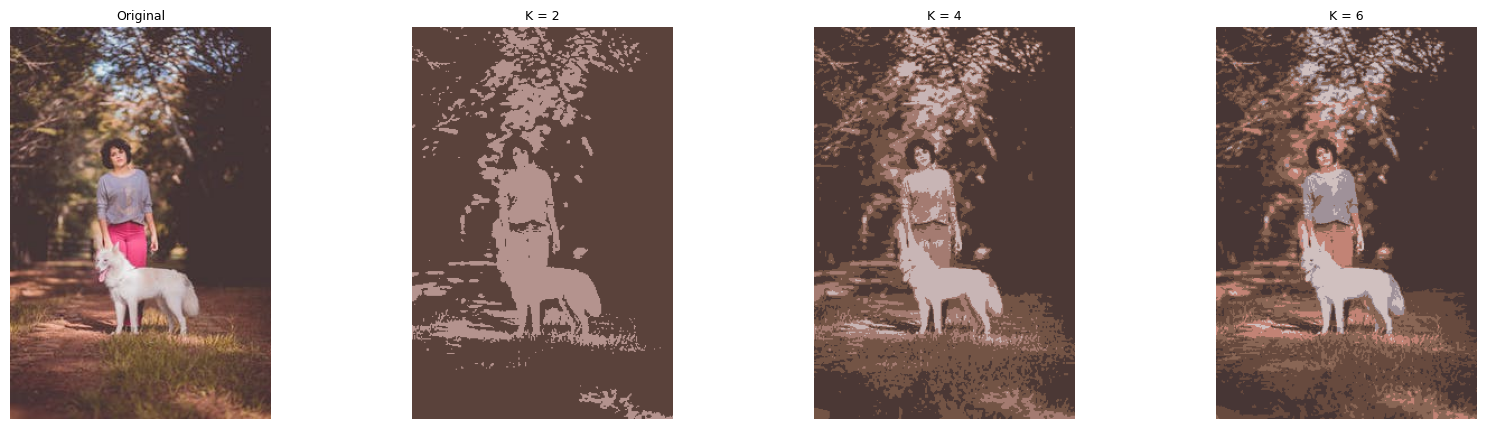

In [15]:
dog = load_color("dog.jpeg")
if max(dog.shape[:2]) > 600:
    s = 600 / max(dog.shape[:2]); dog = cv2.resize(dog, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
Z = dog.reshape((-1, 3)).astype(np.float32)             # pixel feature vectors, float32
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)

def kmeans_segment(K):
    cv2.setRNGSeed(0)
    compactness, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    centers_u8 = np.uint8(centers)
    seg = centers_u8[labels.flatten()].reshape(dog.shape)
    return seg, labels.flatten(), centers_u8, compactness

orig_colors = len(np.unique(Z.astype(np.uint8), axis=0))
segs, rows9 = {}, []
for K in [2, 4, 6]:
    seg, labels, centers, comp = kmeans_segment(K)
    segs[K] = seg
    mse = float(np.mean((seg.astype(np.float32) - dog.astype(np.float32)) ** 2))
    share = np.bincount(labels, minlength=K) / labels.size
    desc = "; ".join(f"RGB{tuple(int(v) for v in c[::-1])} {100*s:.0f}%" for c, s in sorted(zip(centers, share), key=lambda x: -x[1]))
    rows9.append(dict(K=K, clusters=K, colours_remaining=len(np.unique(seg.reshape(-1, 3), axis=0)),
                      colour_reduction=f"{orig_colors} -> {K}", MSE_vs_original=round(mse, 1), regions_represented=desc))
df9 = pd.DataFrame(rows9)
pd.set_option("display.max_colwidth", 200)
print(df9.to_string(index=False))

show_row([dog, segs[2], segs[4], segs[6]], ["Original", "K = 2", "K = 4", "K = 6"],
         fname="task9_kmeans.png", size=4.2)
for K in segs:
    cv2.imwrite(str(OUT_DIR / f"task9_kmeans_K{K}.png"), segs[K])

### Task 9 — observations (typical behaviour; confirm against the table and figure above)

| K | Visual difference from original | Colour simplification | Major regions represented |
|---|---|---|---|
| 2 | Very different: essentially a two-tone poster (light vs dark) | Maximum — all colours collapse to 2 | Broad bright vs dark areas (e.g. background/sky vs animal/shadow) — shape only, colour lost |
| 4 | Recognisable; flat colour patches, visible banding | Strong | Adds the mid-tones/dominant hues: main body colour, highlights and darker details |
| 6 | Closest to the photo; smoother transitions, still clearly "posterised" | Moderate — fewest changes | Separates additional hue families / tonal bands (e.g. different parts of the background, shadows, fur highlights) |

Increasing K lowers the reconstruction error (`MSE_vs_original` decreases) because each pixel is replaced by a closer centre, but the image is simplified less. The exact cluster colours and percentages for **your** run are in the `regions_represented` column.

## Task 10 — Segmentation system for an unknown image

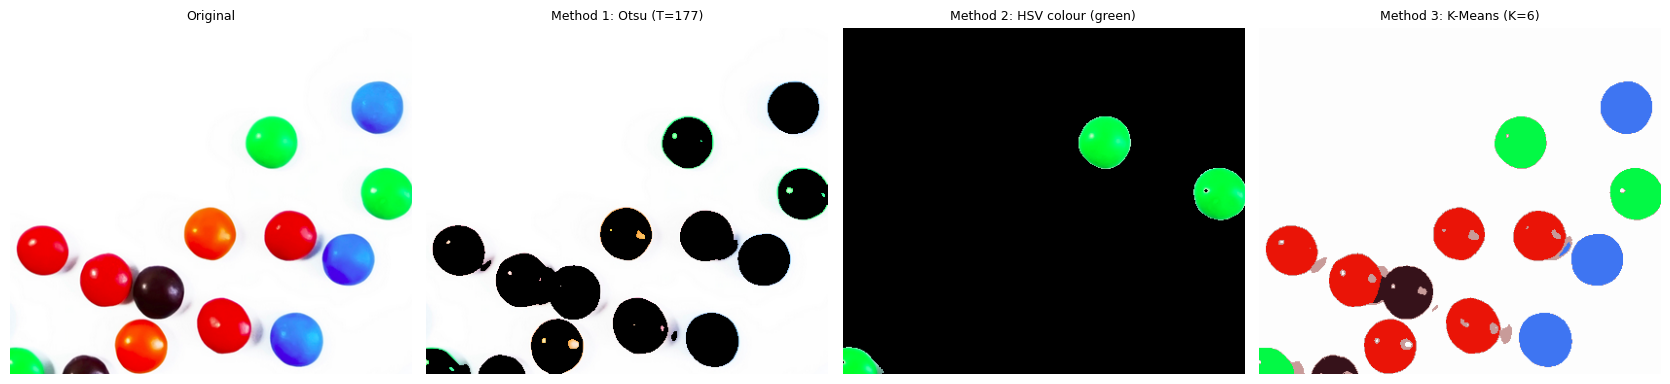

Otsu : foreground 80.3% of image, 17 connected blobs (touching candies fuse into one blob)
HSV  : selected 3.7% of image, 3 green blobs
K-Means centres (RGB): [(253, 253, 253), (234, 20, 7), (3, 249, 69), (62, 117, 242), (54, 18, 26), (200, 155, 153)]
      method / parameter  value  foreground % (K-Means: #regions)
  Otsu: threshold offset    -30                             84.35
  Otsu: threshold offset    -15                             81.17
  Otsu: threshold offset      0                             80.30
  Otsu: threshold offset     15                             79.64
  Otsu: threshold offset     30                             78.97
HSV: hue range shrunk by      0                              3.68
HSV: hue range shrunk by      5                              3.66
HSV: hue range shrunk by     10                              3.56
HSV: hue range shrunk by     20                              0.60
              K-Means: K      3                              3.00
              K-Means:

In [17]:
img10 = load_color("smarties.png")
g10 = cv2.GaussianBlur(cv2.cvtColor(img10, cv2.COLOR_BGR2GRAY), (5, 5), 0)

# Method 1: Otsu
t10, m_otsu = cv2.threshold(g10, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
seg_otsu = cv2.bitwise_and(img10, img10, mask=m_otsu)

# Method 2: colour-based (HSV)
hsv10 = cv2.cvtColor(img10, cv2.COLOR_BGR2HSV)
m_hsv = cv2.inRange(hsv10, np.array((35, 70, 50)), np.array((85, 255, 255)))
seg_hsv = cv2.bitwise_and(img10, img10, mask=m_hsv)

# Method 3: K-Means
def kmeans_img(img, K):
    Zk = img.reshape(-1, 3).astype(np.float32)
    cv2.setRNGSeed(0)
    _, lab, cen = cv2.kmeans(Zk, K, None, (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0), 5, cv2.KMEANS_PP_CENTERS)
    return np.uint8(cen)[lab.flatten()].reshape(img.shape), lab.reshape(img.shape[:2]), np.uint8(cen)
seg_km, lab_km, cen_km = kmeans_img(img10, 6)

show_row([img10, seg_otsu, seg_hsv, seg_km],
         ["Original", f"Method 1: Otsu (T={t10:.0f})", "Method 2: HSV colour (green)", "Method 3: K-Means (K=6)"],
         fname="task10_final_comparison.png", size=4.2)

# Observed quantitative results
n_otsu = cv2.connectedComponents(m_otsu)[0] - 1
n_hsv = cv2.connectedComponents(cv2.morphologyEx(m_hsv, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8)))[0] - 1
print(f"Otsu : foreground {100*(m_otsu>0).mean():.1f}% of image, {n_otsu} connected blobs (touching candies fuse into one blob)")
print(f"HSV  : selected {100*(m_hsv>0).mean():.1f}% of image, {n_hsv} green blobs")
print("K-Means centres (RGB):", [tuple(int(v) for v in c[::-1]) for c in cen_km])

# Parameter sensitivity: how much does each method's foreground change when its key parameter moves?
sens = []
for d in (-30, -15, 0, 15, 30):
    sens.append(("Otsu: threshold offset", d, 100 * (g10 > t10 + d).mean()))
for dh in (0, 5, 10, 20):
    m = cv2.inRange(hsv10, np.array((35 + dh, 70, 50)), np.array((85 - dh, 255, 255)))
    sens.append(("HSV: hue range shrunk by", dh, 100 * (m > 0).mean()))
for K in (3, 6, 9):
    _, l, _c = kmeans_img(img10, K)
    sens.append(("K-Means: K", K, len(np.unique(l))))
print(pd.DataFrame(sens, columns=["method / parameter", "value", "foreground % (K-Means: #regions)"]).round(2).to_string(index=False))

### Task 10 — assumptions, successes, failures, key parameter

**Method 1 — Otsu**
1. *Assumption:* the grey-level histogram is bimodal (object vs background) and illumination is roughly uniform.
2. *Identifies:* all candies as one foreground vs the dark background (a clean object/background mask).
3. *Incorrectly segments:* it cannot tell colours apart; touching candies fuse into one blob; very dark candy parts / the dark printed letters on candies drop out or leave holes.
4. *Most influential parameter:* the grey-level threshold (here chosen automatically); the sensitivity table shows how far the foreground share moves when it is shifted.

**Method 2 — HSV colour threshold**
1. *Assumption:* the object of interest is defined by a distinctive hue, with limited tolerance for brightness changes.
2. *Identifies:* every green candy (and only green), regardless of its position or brightness.
3. *Incorrectly segments:* ignores all other candies by design; highlights on green candies (low saturation) may be missed, and other yellow-green candies near the hue limit may leak in.
4. *Most influential parameter:* the hue range (see the sensitivity table); S/V minimums mainly control background rejection.

**Method 3 — K-Means (K = 6)**
1. *Assumption:* the image consists of a small number of dominant colours, and clusters are roughly spherical in RGB space.
2. *Identifies:* the background and the main candy colour groups in one pass (each candy colour becomes a region).
3. *Incorrectly segments:* it has no spatial awareness — highlights/shadows on a candy get assigned to different clusters (white highlights cluster separately), touching same-colour candies merge, and cluster number is a guess.
4. *Most influential parameter:* **K** — too small merges distinct candy colours, too large splits one colour into shading bands (see the K rows of the sensitivity table).

### Technical conclusion

For this image **K-Means produced the most meaningful regions**: it is the only one of the three that separates the *background* **and** the *different candy colours* in a single result, which is what the outputs above are expected to show — confirm on your run (Otsu gives only a two-class object/background mask and fuses touching candies; HSV isolates a single colour and ignores everything else). K-Means is suitable because the image is defined by **a small set of distinct, saturated colours on a uniform dark background**, i.e. pixel colour alone carries the information that matters. If the task were only counting/locating candies regardless of colour, Otsu followed by watershed (Tasks 3, 7) would be the better choice, and if only a specific colour were needed, HSV thresholding would be.